In [2]:
import pandas as pd
import numpy as np
import random
import networkx as nx
import matplotlib.pyplot as plt

In this network, we will simulate epidemics in well-mixed populations. Our well-mixed population is composed of $N$ individuals, each of them making $k$ contacts with other individuals, randomly chosen from the population. Unlike epidemic in networks (A3), here we do not assume a static heterogeneous structure of contacts. Instead, contacts are reshuffled each time step

### Function to perform the simulations

In this code, we will simulate a SIR dynamics. The condition to finish epidemics generated by the SIR model is clear, as every outbreak finishes when there are no more infected individuals. Note that this does not apply to the SIS model, as in the latter case the steady state of the dynamics corresponds to an endemic equilibrium of infected and healthy population. The students in the activity should then fix either a maximum number of time steps (discouraged) or check whether the density of infected individuals is stable over time (encouraged).

In [3]:
def SIR_well_mixed(N,I0,k,R0,mu,nrealizations=1):
    """
    Simulates the SIR model on a well-mixed population.
    N: Total population size
    I: Number of initially infected individuals
    k: Number of contacts
    R0: Basic reproduction number
    mu: Recovery probability
    """
    
    df = pd.DataFrame(columns=['realization','t','S', 'I', 'R']) ## DataFrame to store the results
    row=0
    for realization in range(nrealizations):
    # Initialize the state of each individual (S, I, R)
        S = N - I0  # Susceptible individuals
        I = I0  # Infected individuals
        R = 0  # Recovered individuals

        lambda_ = R0 * mu / k  # infection probability


        # Create a DataFrame to store the results
        t=0
        while (I > 0):
            df.loc[row] = [realization,t,S, I, R]
            # Calculate the number of new infections and recoveries
            new_infections = 0  # Infections
            new_recoveries = 0  # Recoveries
            
            for i in range(S):
                for contacts in range(k):
                    random_number = random.random()
                    if random_number < lambda_ * I / N: ## The second term is because we are assuming that the population is well-mixed and the probability of choosing an infected individual is I/N. In a network, contagions can only occur among neighbors. 
                        new_infections += 1
                        break
            for i in range(I):
                random_number = random.random()
                if random_number < mu:
                    new_recoveries += 1

            # Update the counts of susceptible, infected, and recovered individuals
            S -= new_infections
            I += new_infections - new_recoveries
            R += new_recoveries

            # Store the results in the DataFrame
            t+=1
            row+=1

        df.loc[row] = [realization,t,S, I, R]
        row+=1

    return df

In [4]:

## Let us set the size of the population, the number of initially infected individuals, the epidemiological parameters, and the number of time steps.

N = 1000  # Total population size
I = 10  # Number of initially infected individuals
k=6  # Number of contacts
mu = 0.1  # Recovery probability (Average infection duration=1/mu)

########################
R0=0.5
df_results_subcritical=SIR_well_mixed(N,I, k, R0, mu)

R0=2
df_results_supercritical=SIR_well_mixed(N,I, k, R0, mu)

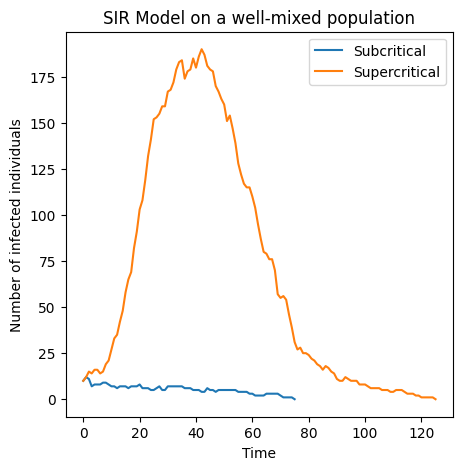

In [5]:
fig,ax=plt.subplots(1,1,figsize=(5,5))

ax.plot(df_results_subcritical['t'],df_results_subcritical['I'],label='Subcritical')
ax.plot(df_results_supercritical['t'],df_results_supercritical['I'],label='Supercritical')
ax.set_xlabel('Time')
ax.set_ylabel('Number of infected individuals')
ax.legend()
plt.title('SIR Model on a well-mixed population')
plt.show()

Let us now reflect the stochastic nature of the simulations by performing multiple realizations (outbreaks) for the same epidemiological parameters

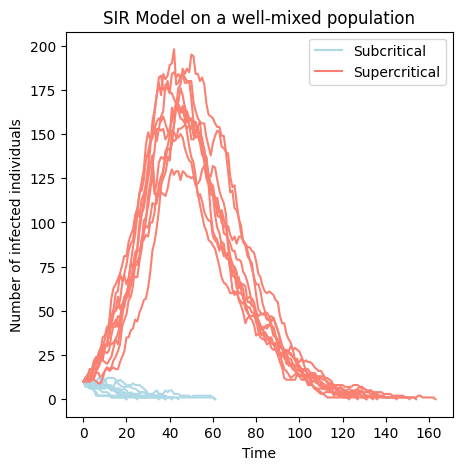

In [6]:
nrealizations=10

R0=0.5
df_results_subcritical=SIR_well_mixed(N,I, k, R0, mu,nrealizations)

R0=2
df_results_supercritical=SIR_well_mixed(N,I, k, R0,mu,nrealizations)


fig,ax=plt.subplots(1,1,figsize=(5,5))

color_subcritical='lightblue'
color_supercritical='salmon'

for realization in range(nrealizations):
    aux_subcritical=df_results_subcritical[df_results_subcritical['realization']==realization]
    aux_supercritical=df_results_supercritical[df_results_supercritical['realization']==realization]
    if(realization==0):
        ax.plot(aux_subcritical['t'],aux_subcritical['I'],color=color_subcritical,alpha=1,label='Subcritical')
        ax.plot(aux_supercritical['t'],aux_supercritical['I'],color=color_supercritical,alpha=1,label='Supercritical')
    else:
        ax.plot(aux_subcritical['t'],aux_subcritical['I'],color=color_subcritical,alpha=1)
        ax.plot(aux_supercritical['t'],aux_supercritical['I'],color=color_supercritical,alpha=1)
ax.set_xlabel('Time')
ax.set_ylabel('Number of infected individuals')
ax.legend()
plt.title('SIR Model on a well-mixed population')
plt.show()


### Epidemic diagrams

The idea now is to construct the epidemic diagrams. For the SIR model, the severity of the outbreak is quantified by the total number of individuals affected by the outbreak. As all contracting the disease at some point of the outbreak will end up in the Recovered compartment, we can just retrieve this information by looking at the occupation of this compartment at the end of the dynamics. Let us modify the former function of the SIR model to decide the outcome

In [7]:
def SIR_well_mixed_epidemic_diagram(N,I0,k,R0_values,mu,nrealizations):
    """
    Simulates the SIR model on a well-mixed population.
    N: Total population size
    I: Number of initially infected individuals
    k: Number of contacts
    R0: Basic reproduction number
    mu: Recovery probability
    """
    
    df = pd.DataFrame(columns=['realization','R0','attack_rate']) ## DataFrame to store the results
    row=0
    for R0 in R0_values:
        for realization in range(nrealizations):
        # Initialize the state of each individual (S, I, R)
            S = N - I0  # Susceptible individuals
            I = I0  # Infected individuals
            R = 0  # Recovered individuals

            lambda_ = R0 * mu / k  # infection probability


            # Create a DataFrame to store the results
            t=0
            while (I > 0):
                # Calculate the number of new infections and recoveries
                new_infections = 0  # Infections
                new_recoveries = 0  # Recoveries
                
                for i in range(S):
                    for contacts in range(k):
                        random_number = random.random()
                        if random_number < lambda_ * I / N: ## The second term is because we are assuming that the population is well-mixed and the probability of choosing an infected individual is I/N. In a network, contagions can only occur among neighbors. 
                            new_infections += 1
                            break
                for i in range(I):
                    random_number = random.random()
                    if random_number < mu:
                        new_recoveries += 1

                # Update the counts of susceptible, infected, and recovered individuals
                S -= new_infections
                I += new_infections - new_recoveries
                R += new_recoveries

                # Store the results in the DataFrame

            df.loc[row] = [realization,R0,R/N]
            row+=1
            print('R0:%.2lf realization %d'%(R0,realization))

    return df

In [8]:

N = 1000  # Total population size
I = 10  # Number of initially infected individuals
k=6  # Number of contacts
mu = 0.1  # Recovery probability (Average infection duration=1/mu)

R0_values=np.linspace(0.5,2.5,21)
nrealizations=50
df_results_epidemic_diagram=SIR_well_mixed_epidemic_diagram(N,I, k, R0_values, mu,nrealizations)

R0:0.50 realization 0
R0:0.50 realization 1
R0:0.50 realization 2
R0:0.50 realization 3
R0:0.50 realization 4
R0:0.50 realization 5
R0:0.50 realization 6
R0:0.50 realization 7
R0:0.50 realization 8
R0:0.50 realization 9
R0:0.50 realization 10
R0:0.50 realization 11
R0:0.50 realization 12
R0:0.50 realization 13
R0:0.50 realization 14
R0:0.50 realization 15
R0:0.50 realization 16
R0:0.50 realization 17
R0:0.50 realization 18
R0:0.50 realization 19
R0:0.50 realization 20
R0:0.50 realization 21
R0:0.50 realization 22
R0:0.50 realization 23
R0:0.50 realization 24
R0:0.50 realization 25
R0:0.50 realization 26
R0:0.50 realization 27
R0:0.50 realization 28
R0:0.50 realization 29
R0:0.50 realization 30
R0:0.50 realization 31
R0:0.50 realization 32
R0:0.50 realization 33
R0:0.50 realization 34
R0:0.50 realization 35
R0:0.50 realization 36
R0:0.50 realization 37
R0:0.50 realization 38
R0:0.50 realization 39
R0:0.50 realization 40
R0:0.50 realization 41
R0:0.50 realization 42
R0:0.50 realization 4

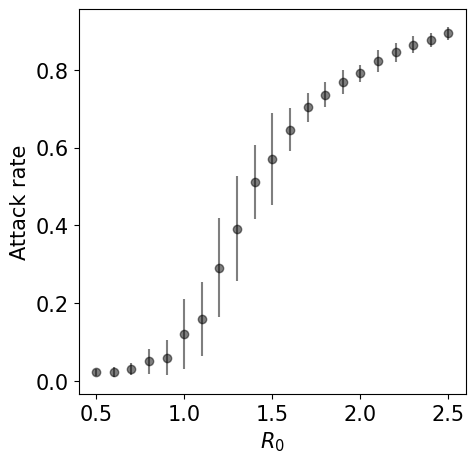

In [9]:
df_results_epidemic_diagram['R0']=df_results_epidemic_diagram['R0'].astype(float)
df_results_epidemic_diagram['attack_rate']=df_results_epidemic_diagram['attack_rate'].astype(float)
fig,ax=plt.subplots(1,1,figsize=(5,5))
df_grouped=df_results_epidemic_diagram.groupby(['R0']).agg({'attack_rate':['mean','std']}).reset_index()
ax.errorbar(df_grouped['R0'],df_grouped['attack_rate']['mean'],yerr=df_grouped['attack_rate']['std'],fmt='o',color='black',alpha=0.5)
ax.set_xlabel('$R_0$',fontsize=15)
ax.set_ylabel('Attack rate',fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)

### Use the results from the theoretical equations

We have two theoretical approaches: One based on the mean-field equations (MF), which constitutes a continuous-time approach enabling analytical results and another one based on the Microscopic Markov Chain Approach (MMCA), representing discrete-time equations, more similar in nature to the discrete-time simulations performed in the previous points. 

Note that, in principle, epidemics unfold in continuous time (if the time step is small enough only one process takes place each step) but, for simplicity, discrete-time approaches are adopted. Ideally, the time step should be very small so both approaches yield comparable results. 

As the analytical expressions for the attack rate using the continuous time MF equations are quite cumbersome, we will integrate numerically the equations to obtain the results

#### MF approach for the SIR model

\begin{align}
\dot{S} &= - \lambda k S I/N \\ 
\dot{I} &=  \lambda k S I/N - \mu I \\
\dot{R} &=  \mu I 
\end{align}

In [10]:
## Integrate the dynamical equations of the SIR model
def MF_SIR_model(y,t, N, k, R0, mu):
    S, I, R = y
    lambda_ = R0 * mu / k  # infection probability

    dSdt = -lambda_ * k* S * float(I) / N
    dIdt = lambda_ * k*S * float(I) / N - mu * I
    dRdt = mu * I

    return [dSdt, dIdt, dRdt]

In [11]:
t_span = np.linspace(0, 1000, 1000)  # Time span for the simulation

N = 1000  # Total population size
I = 10  # Number of initially infected individuals
k = 6  # Number of contacts
mu = 0.1  # Recovery probability (Average infection duration=1/mu)


y0 = [N - I, I, 0]  # Initial conditions: S, I, R
from scipy.integrate import odeint
attack_rate_values_MF=[]

for R0 in R0_values:
    MF_R=odeint(MF_SIR_model, y0, t_span, args=(N, k, R0, mu))
    attack_rate_values_MF.append(MF_R[-1, 2] / N)  # Attack rate is the final number of recovered individuals divided by the total population size


In [12]:
attack_rate_values_MF

[np.float64(0.01970712193058687),
 np.float64(0.02437111325102644),
 np.float64(0.03178117430732366),
 np.float64(0.04502588614371154),
 np.float64(0.07271229524100604),
 np.float64(0.13515695612458162),
 np.float64(0.2381957425440694),
 np.float64(0.3478189627472968),
 np.float64(0.4445273240735867),
 np.float64(0.5258623870443899),
 np.float64(0.5936342967264453),
 np.float64(0.6501814198600696),
 np.float64(0.697578657295992),
 np.float64(0.7375229589819506),
 np.float64(0.7713712286134449),
 np.float64(0.8002039689489481),
 np.float64(0.8248840168899113),
 np.float64(0.8461042079153389),
 np.float64(0.8644245142498156),
 np.float64(0.8803006171514639),
 np.float64(0.8941058058663598)]

#### MMCA in a well-mixed population

\begin{align}
\rho_S(t+1) &=  \rho_S (t) (1-\lambda\rho_I (t))^k \\ 
\rho_I(t+1) &=  (1- \mu) \rho_I (t) + \rho_S (t) \left(1-(1-\lambda\rho_I(t))^k\right)  \\
\rho_R (t+1) &= \rho_R (t) +  \mu \rho_I (t)
\end{align}

In [13]:
### Code to iterate the MMCA equations of the SIR model

def iterateSIR_MMCA_MF_attack_rate(N, I0, k, R0, mu):
    rho_S=1-I0/N
    rho_I=I0/N
    rho_R=0
    lambda_=R0*mu/k
    ############## MMCA equations
    
    rho=[rho_S,rho_I,rho_R]
    while(rho[1]>0.001/N):
        rho_old=rho.copy()
        contagion_prob=1-(1-lambda_*rho_old[1])**k
        rho[0]=rho_old[0]*(1-contagion_prob)
        rho[1]=(1-mu)*rho_old[1]+rho_old[0]*contagion_prob
        rho[2]=rho_old[2]+rho_old[1]*mu

    return rho[2]  # Return the attack rate (final number of recovered individuals divided by the total population size)

In [14]:
## Epidemic diagram according to the MMCA equations

R0_values=np.linspace(0.5,2.5,21)
attack_rate_values_MMCA=[]
mu=0.1
for R0 in R0_values:
    attack_rate_values_MMCA.append(iterateSIR_MMCA_MF_attack_rate(N, I, k, R0, mu))  # Attack rate is the final number of recovered individuals divided by the total population size

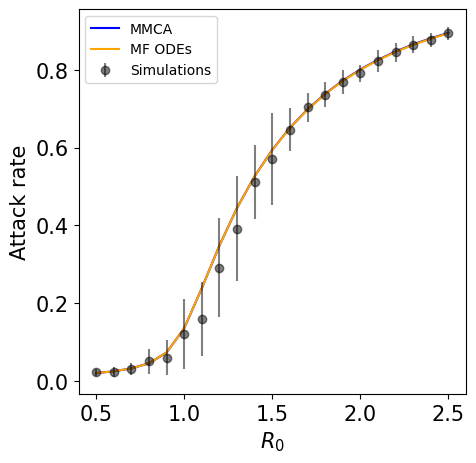

In [15]:
### Represent results from simulations and theory (MMCA equations and MF ODEs)
fig,ax=plt.subplots(1,1,figsize=(5,5))
ax.plot(R0_values,attack_rate_values_MMCA,label='MMCA',color='blue')
ax.plot(R0_values,attack_rate_values_MF,label='MF ODEs',color='orange')
ax.errorbar(df_grouped['R0'],df_grouped['attack_rate']['mean'],yerr=df_grouped['attack_rate']['std'],fmt='o',color='black',alpha=0.5,label='Simulations')
ax.set_xlabel('$R_0$',fontsize=15)
ax.set_ylabel('Attack rate',fontsize=15)
ax.legend()
ax.tick_params(axis='both', which='major', labelsize=15)